In [131]:
%matplotlib inline

In [132]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings("ignore")

In [133]:
RESULTS_DIR = r"D:\003 COMPUTER SCIENCE\FOURTH SEMESTER\Research Methodology in CS\Emotion Classification in E-Commerce\results"

XLMR_PATH   = os.path.join(RESULTS_DIR, "xlmr_predictions.csv")
INDO_PATH   = os.path.join(RESULTS_DIR, "indobert_predictions.csv")
BILSTM_PATH = os.path.join(RESULTS_DIR, "bilstm_fasttext_predictions.csv")

LABEL_NAMES = ["Anger", "Fear", "Happy", "Love", "Sadness"]
MODEL_NAMES = ["XLM-R", "IndoBERT", "BiLSTM+FastText"]
COLORS      = ["#4C72B0", "#DD8452", "#55A868"]

In [134]:
xlmr_df   = pd.read_csv(XLMR_PATH)
indo_df   = pd.read_csv(INDO_PATH)
bilstm_df = pd.read_csv(BILSTM_PATH)

assert (xlmr_df["label"].values == indo_df["label"].values).all()
assert (xlmr_df["label"].values == bilstm_df["label"].values).all()

y_true = xlmr_df["label"].values
preds  = {
    "XLM-R"          : xlmr_df["predicted_label"].values,
    "IndoBERT"       : indo_df["predicted_label"].values,
    "BiLSTM+FastText": bilstm_df["predicted_label"].values,
}

In [135]:
rows = []
for name, y_pred in preds.items():
    rows.append({
        "Model"       : name,
        "Accuracy"    : accuracy_score(y_true, y_pred),
        "Weighted F1" : f1_score(y_true, y_pred, average="weighted"),
        "Macro F1"    : f1_score(y_true, y_pred, average="macro"),
        "Macro Prec." : precision_score(y_true, y_pred, average="macro"),
        "Macro Recall": recall_score(y_true, y_pred, average="macro"),
    })

summary_df = pd.DataFrame(rows).set_index("Model")
print("AGGREGATE METRICS (Test Set, n=526)")
print(summary_df.to_string(float_format=lambda x: f"{x:.4f}"))

AGGREGATE METRICS (Test Set, n=526)
                 Accuracy  Weighted F1  Macro F1  Macro Prec.  Macro Recall
Model                                                                      
XLM-R              0.7243       0.7255    0.7015       0.7026        0.7090
IndoBERT           0.7205       0.7160    0.6878       0.6926        0.6918
BiLSTM+FastText    0.5760       0.5774    0.5380       0.5503        0.5336


In [136]:
per_class = {}
for name, y_pred in preds.items():
    report = classification_report(
        y_true, y_pred,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0,
    )
    per_class[name] = {cls: report[cls]["f1-score"] for cls in LABEL_NAMES}

per_class_df = pd.DataFrame(per_class).T
print("PER-CLASS F1-SCORE")
print(per_class_df.to_string(float_format=lambda x: f"{x:.4f}"))

PER-CLASS F1-SCORE
                 Anger   Fear  Happy   Love  Sadness
XLM-R           0.6613 0.5393 0.8606 0.7797   0.6667
IndoBERT        0.6032 0.5350 0.8415 0.7529   0.7063
BiLSTM+FastText 0.5217 0.2825 0.7836 0.5750   0.5271


In [137]:
for name, y_pred in preds.items():
    print(f"\n{'─'*60}")
    print(f"{name} — Classification Report")
    print(classification_report(
        y_true, y_pred,
        target_names=LABEL_NAMES,
        digits=4,
        zero_division=0,
    ))


────────────────────────────────────────────────────────────
XLM-R — Classification Report
              precision    recall  f1-score   support

       Anger     0.7193    0.6119    0.6613        67
        Fear     0.5393    0.5393    0.5393        89
       Happy     0.9161    0.8114    0.8606       175
        Love     0.6900    0.8961    0.7797        77
     Sadness     0.6480    0.6864    0.6667       118

    accuracy                         0.7243       526
   macro avg     0.7026    0.7090    0.7015       526
weighted avg     0.7340    0.7243    0.7255       526


────────────────────────────────────────────────────────────
IndoBERT — Classification Report
              precision    recall  f1-score   support

       Anger     0.6441    0.5672    0.6032        67
        Fear     0.6176    0.4719    0.5350        89
       Happy     0.8488    0.8343    0.8415       175
        Love     0.6882    0.8312    0.7529        77
     Sadness     0.6642    0.7542    0.7063       118

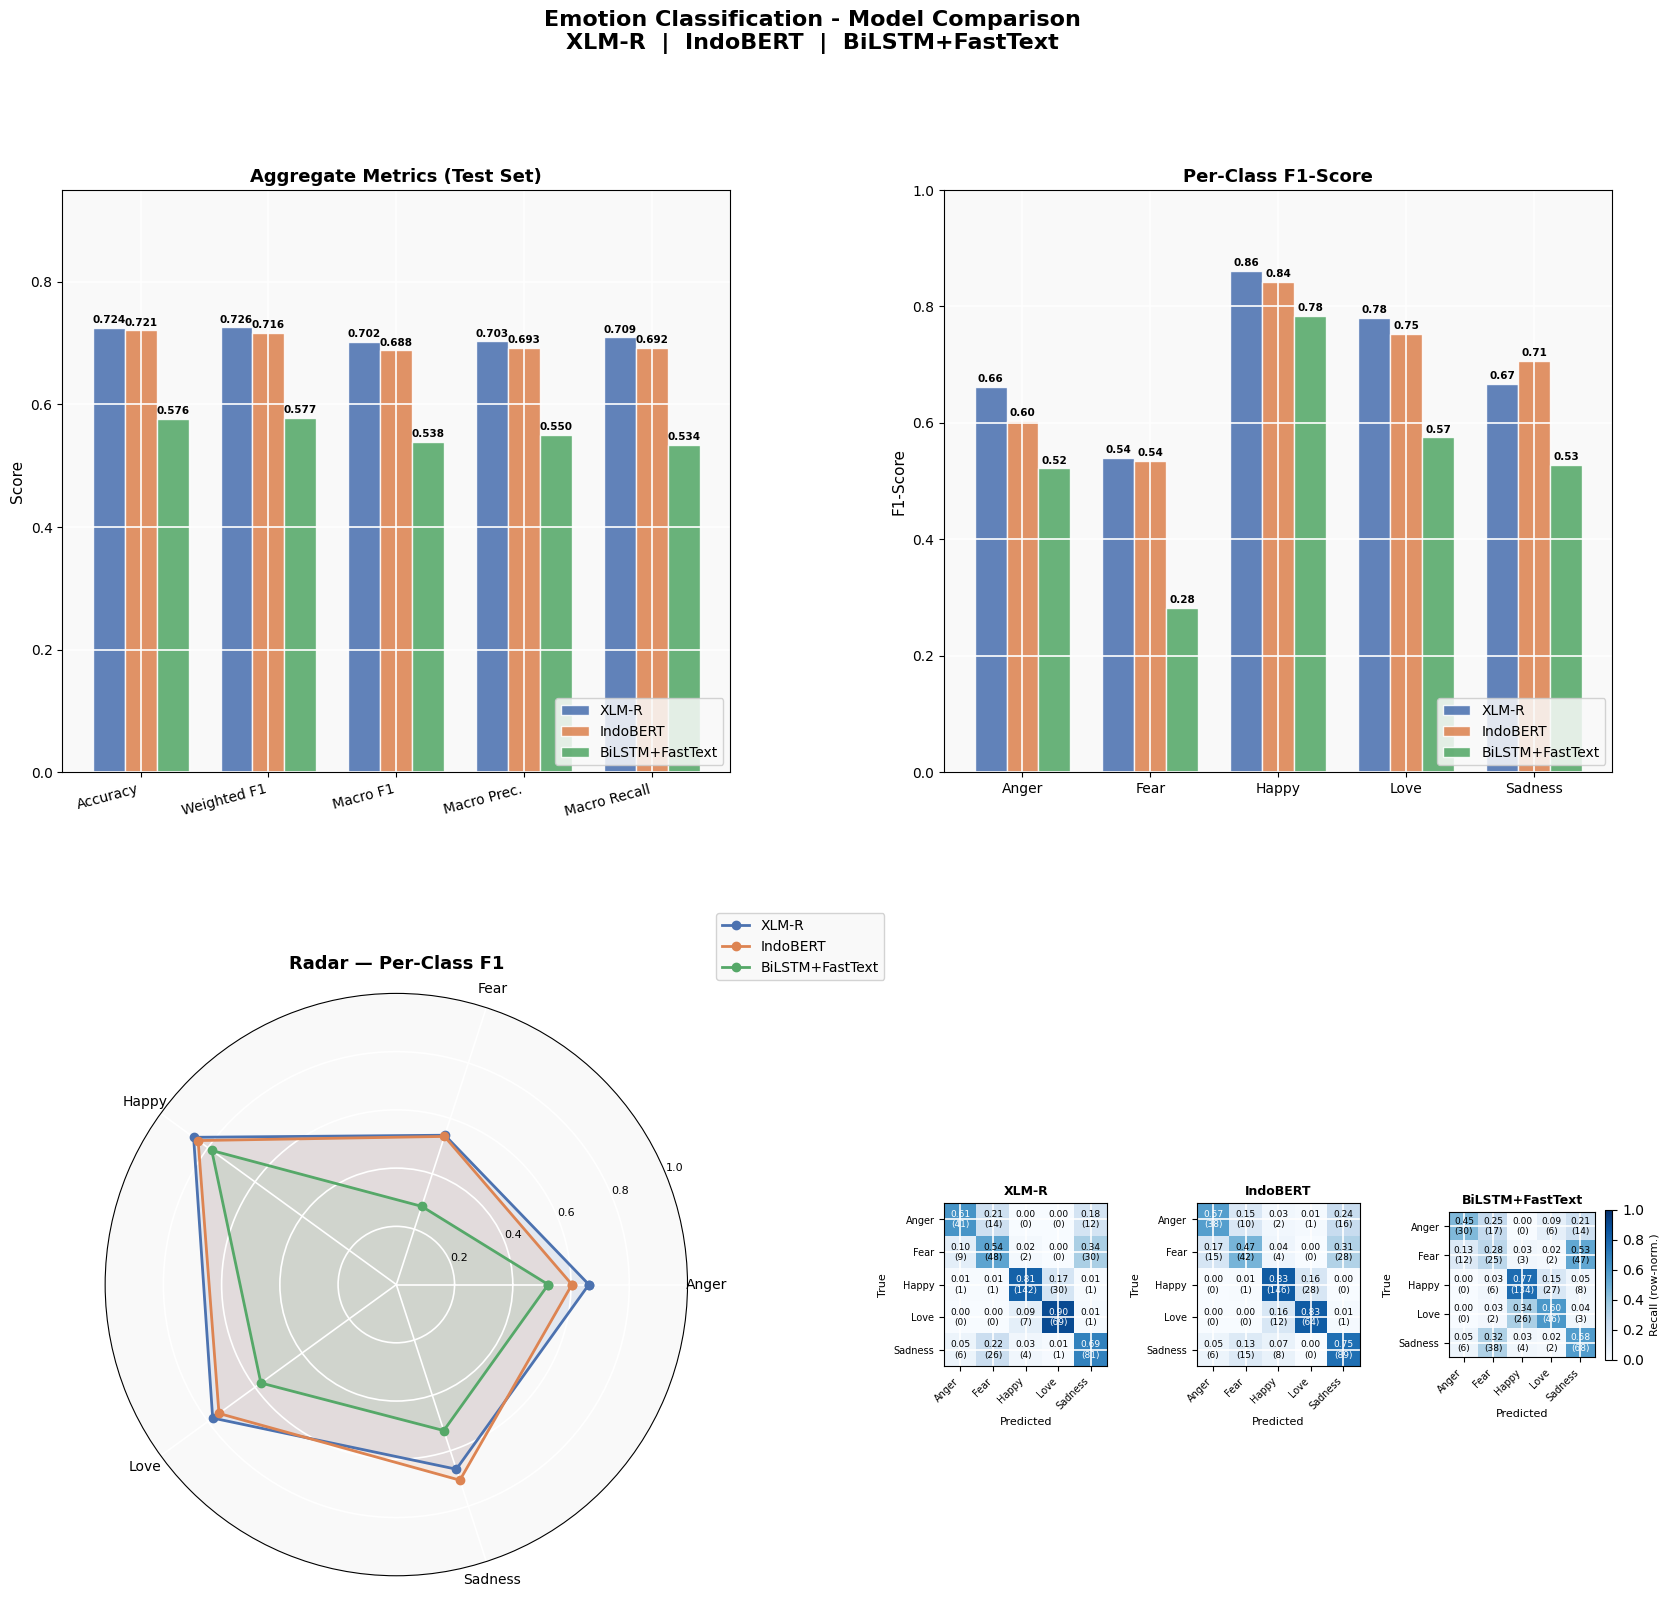

In [138]:
plt.close("all")
plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#F9F9F9",
    "axes.grid"        : True,
    "grid.color"       : "white",
    "grid.linewidth"   : 1.2,
    "font.family"      : "DejaVu Sans",
    "font.size"        : 11,
    "axes.titlesize"   : 13,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 11,
    "xtick.labelsize"  : 10,
    "ytick.labelsize"  : 10,
    "legend.fontsize"  : 10,
})

fig = plt.figure(figsize=(20, 18))
fig.suptitle(
    "Emotion Classification - Model Comparison\n"
    "XLM-R  |  IndoBERT  |  BiLSTM+FastText",
    fontsize=16, fontweight="bold", y=0.98,
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# ── Aggregate metrics bar chart ───────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
metrics   = ["Accuracy", "Weighted F1", "Macro F1", "Macro Prec.", "Macro Recall"]
x         = np.arange(len(metrics))
bar_width = 0.25

for i, (name, color) in enumerate(zip(MODEL_NAMES, COLORS)):
    vals = [summary_df.loc[name, m] for m in metrics]
    bars = ax1.bar(x + i * bar_width, vals, bar_width,
                   label=name, color=color, alpha=0.88, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax1.set_xticks(x + bar_width)
ax1.set_xticklabels(metrics, rotation=15, ha="right")
ax1.set_ylim(0, 0.95)
ax1.set_title("Aggregate Metrics (Test Set)")
ax1.set_ylabel("Score")
ax1.legend(loc="lower right", framealpha=0.85)

# ── Per-class F1 bar chart ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
x2 = np.arange(len(LABEL_NAMES))

for i, (name, color) in enumerate(zip(MODEL_NAMES, COLORS)):
    vals = [per_class[name][cls] for cls in LABEL_NAMES]
    bars = ax2.bar(x2 + i * bar_width, vals, bar_width,
                   label=name, color=color, alpha=0.88, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005, f"{val:.2f}",
                 ha="center", va="bottom", fontsize=7.5, fontweight="bold")

ax2.set_xticks(x2 + bar_width)
ax2.set_xticklabels(LABEL_NAMES)
ax2.set_ylim(0, 1.0)
ax2.set_title("Per-Class F1-Score")
ax2.set_ylabel("F1-Score")
ax2.legend(loc="lower right", framealpha=0.85)

# ── Radar chart ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0], polar=True)
angles = np.linspace(0, 2 * np.pi, len(LABEL_NAMES), endpoint=False).tolist()
angles += angles[:1]

for name, color in zip(MODEL_NAMES, COLORS):
    vals = [per_class[name][cls] for cls in LABEL_NAMES] + \
           [per_class[name][LABEL_NAMES[0]]]
    ax3.plot(angles, vals, "o-", linewidth=2, color=color, label=name)
    ax3.fill(angles, vals, alpha=0.12, color=color)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(LABEL_NAMES, size=10)
ax3.set_ylim(0, 1)
ax3.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax3.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], size=8)
ax3.set_title("Radar — Per-Class F1", pad=18)
ax3.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), framealpha=0.85)

# ── Confusion matrices ────────────────────────────────────────
inner_gs = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs[1, 1], wspace=0.55,
)
cm_axes = [fig.add_subplot(inner_gs[0, j]) for j in range(3)]
cm_axes[1].set_title("Confusion Matrices (row-normalised)",
                      fontsize=11, fontweight="bold", pad=30)

for ax, (name, y_pred) in zip(cm_axes, preds.items()):
    cm   = confusion_matrix(y_true, y_pred)
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im   = ax.imshow(cm_n, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(LABEL_NAMES)))
    ax.set_yticks(range(len(LABEL_NAMES)))
    ax.set_xticklabels(LABEL_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(LABEL_NAMES, fontsize=7)
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("True", fontsize=8)

    for r in range(len(LABEL_NAMES)):
        for c in range(len(LABEL_NAMES)):
            val     = cm_n[r, c]
            raw     = cm[r, c]
            color_t = "white" if val > 0.55 else "black"
            ax.text(c, r, f"{val:.2f}\n({raw})",
                    ha="center", va="center", fontsize=6.5, color=color_t)

fig.colorbar(im, ax=cm_axes[-1], fraction=0.046, pad=0.06).set_label(
    "Recall (row-norm.)", fontsize=8
)

plt.savefig(os.path.join(RESULTS_DIR, "comparison_dashboard.png"),
            dpi=150, bbox_inches="tight")
plt.show();

In [139]:
final_rows = []
for name, y_pred in preds.items():
    report = classification_report(
        y_true, y_pred,
        target_names=LABEL_NAMES,
        output_dict=True,
        zero_division=0,
    )
    row = {"Model": name}
    for cls in LABEL_NAMES:
        row[f"{cls}_precision"] = report[cls]["precision"]
        row[f"{cls}_recall"]    = report[cls]["recall"]
        row[f"{cls}_f1"]        = report[cls]["f1-score"]
    row["accuracy"]     = report["accuracy"]
    row["macro_f1"]     = report["macro avg"]["f1-score"]
    row["macro_prec"]   = report["macro avg"]["precision"]
    row["macro_recall"] = report["macro avg"]["recall"]
    row["weighted_f1"]  = report["weighted avg"]["f1-score"]
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)
final_df.to_csv(os.path.join(RESULTS_DIR, "final_comparison.csv"), index=False)
print("Saved: results/final_comparison.csv")
print(final_df[["Model", "accuracy", "macro_f1", "weighted_f1"]].to_string(index=False))

Saved: results/final_comparison.csv
          Model  accuracy  macro_f1  weighted_f1
          XLM-R  0.724335  0.701510     0.725500
       IndoBERT  0.720532  0.687799     0.716005
BiLSTM+FastText  0.576046  0.537997     0.577393
